In [1]:
import os
from pathlib import Path
import sys


# 프로젝트 루트 경로를 찾아 src 폴더를 sys.path에 추가합니다.
def find_project_root() -> Path:
    curr = Path.cwd()
    for parent in [curr] + list(curr.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return curr

PROJECT_ROOT = find_project_root()
src_dir = str(PROJECT_ROOT / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

os.environ.setdefault("LANGSMITH_TRACING", "true")

'true'

In [2]:
from langchain_community.document_loaders import PyPDFLoader

# 프로젝트 루트를 기준으로 경로를 설정합니다.
file_path = str(PROJECT_ROOT / "data/raw/pdf/saving_tips/1.pdf")
loader = PyPDFLoader(file_path=file_path)
docs = loader.load()

print(f"불러온 문서 수: {len(docs)}")
print(docs[1].page_content)

불러온 문서 수: 9
- 2 -
금융꿀팁 200선-㉚제 목사회초년생을 위한 금융꿀팁 7가지
사 례
l(사례1) 사회초년생 김준성(31세)씨는 신년모임에서 친구들로부터 결혼준비, 주택마련, 노후준비 등을 위해 장래에 필요한 자금계획을 세우고 다양한 금융상품에 가입하고 있다는 이야기를 들음.   김준성씨도 올해부터는 계획을 세워서 장래에 필요한 자금을 모아야겠다고 다짐하였으나 막상 무엇부터 어떻게 해야 할지 막막해 하고 있음. l(사례2) 사회초년생 이한별(28세)씨는 취업후 결혼을 계획하고 결혼자금으로 5천만원의 대출이 필요하여 은행을 방문해 상담하였으나 신용등급이 낮아 대출이 곤란하다며 거절당함.    그동안 쉽고 편리하다는 이유로 신용카드 현금서비스를 자주 이용하였고 TV광고에 자주 나오는 저축은행과 대부업체의 대출을 무심코 이용하여 신용등급이 낮아져 은행대출이 거절된 것을 알고 신용관리를 제대로 하지 못한 것을 후회하고 있음.l(사례3) 사회초년생 서동수(30세)씨는 작년 첫 월급날 보험설계사인 선배의 권유로 종신보험, 변액CI보험 등 여러 개의 보험을 가입함.       최근 서씨는 보험료 부담도 되고 결혼자금도 필요하여 종신보험을 해지하려고 보험사에 문의했으나 해약환급금이 거의 없어 손해가 발생한다는 사실을 알게 되었음.


In [3]:
# 검증: 문서가 정상적으로 로드되었는지 확인
assert len(docs) > 0, "문서가 로드되지 않았습니다."
assert all(hasattr(d, 'page_content') for d in docs), "문서 객체 형식이 올바르지 않습니다."

In [25]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n"],
    chunk_size=300,
    chunk_overlap=50,
    length_function=len
)

# 여기를 split_documents로 바꿨어요!
split_docs = text_splitter.split_documents(docs)
print(f"청킹된 문서 수: {len(split_docs)}")

청킹된 문서 수: 5


In [26]:
# 검증: 청킹이 정상적으로 수행되었는지 확인
assert len(split_docs) >= len(docs), "청킹 후 문서 수가 줄어들 수 없습니다."
assert len(split_docs) > 0, "청킹된 문서가 없습니다."

In [27]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001F8D298A000>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001F8D29931D0>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [28]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(split_docs, embeddings)

print(f"인덱싱된 총 벡터 수: {vectorstore.index.ntotal}")

인덱싱된 총 벡터 수: 5


In [29]:
# 검증: 벡터스토어에 인덱싱된 문서 확인
assert vectorstore.index.ntotal > 0, "벡터스토어에 인덱싱된 데이터가 없습니다."

In [30]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 6})

In [31]:
query = "사회초년생을 위한 금융꿀팁 7가지"

# invoke() 메서드로 문서 검색
res = retriever.invoke(query)

print(f"검색 결과 수: {len(res)}")
for i in res:
    print(i.page_content[:100] + "...")
    print("=" * 100)

검색 결과 수: 5
- 3 -
제 목사회초년생을 위한 금융꿀팁 7가지
꿀 팁
☞ 사회초년생을 위한 금융꿀팁 7가지를 기억하고 실천해 보세요.
 ① 「파인」과 친해지기 학교를 졸업하고 사회생활을 시작하...
- 7 -
제 목사회초년생을 위한 금융꿀팁 7가지   ⑤ 종잣돈 모으기   사회생활을 시작하여 월급을 받게 되면 비록 적은 금액이라도 꾸준히 저축하여 이른바 “종잣돈”을 모으는 것...
- 9 -
제 목사회초년생을 위한 금융꿀팁 7가지  ⑦ 현금서비스 등 자제하기 사회생활을 시작하면 의외로 돈 쓸 곳이 많아져 현금서비스나 카드론을 이용하고, 심지어 대부업체에서 고...
- 6 -
제 목사회초년생을 위한 금융꿀팁 7가지 주거래 은행을 정할 때는 자신이 앞으로 많이 이용할 금융서비스에 대한 혜택뿐만 아니라 이용편의성 등을 종합적으로 고려할 필요가 있...
- 4 -
제 목사회초년생을 위한 금융꿀팁 7가지「파인」에 들어가면 금융상품을 한 눈에 비교할 수 있을 뿐만 아니라, 자신의 계좌나 금융거래 내역을 조회할 수 있으며, 금감원이 매...


In [32]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

context_texts = [doc.page_content for doc in res]

answer = llm.invoke(
    f"""
    질문: {query}

    아래 정보를 바탕으로 답변하세요:
    {context_texts}
    """
).content

print("최종 답변:")
print(answer)

최종 답변:
사회초년생을 위한 금융꿀팁 7가지를 소개합니다. 이 팁들을 기억하고 실천하면 건강한 금융생활을 시작하는 데 큰 도움이 될 것입니다.

1. **「파인」과 친해지기**: 금융감독원이 운영하는 금융소비자정보포털사이트 「파인」(fine.fss.or.kr)을 활용하여 실용적인 금융정보를 파악하고 이용하세요. 금융상품 비교, 계좌 조회, 금융꿀팁 정보 등을 쉽게 얻을 수 있습니다.

2. **신용등급에 관심 기울이기**: 개인 신용등급은 금융거래에서 매우 중요합니다. 대출신청 시 신용등급에 따라 대출 가능 여부와 금리가 달라지므로, 정기적으로 자신의 신용등급을 확인하고 관리하는 습관을 가지세요.

3. **주거래은행 정하기**: 자주 이용할 금융서비스의 혜택과 이용 편의성을 고려하여 주거래은행을 정하세요. 자동이체 계좌를 다른 은행으로 옮길 때는 「파인」의 페이인포나 어카운트인포를 활용하면 편리합니다.

4. **체크카드 사용하기**: 신용카드 대신 체크카드를 사용하는 것이 좋습니다. 체크카드는 대출 기능이 없고, 자신의 예금 범위 내에서만 결제가 가능하여 합리적인 소비를 유도합니다. 또한, 체크카드는 소득공제율이 신용카드보다 높아 연말정산에도 유리합니다.

5. **종잣돈 모으기**: 월급을 받기 시작하면 적은 금액이라도 꾸준히 저축하여 종잣돈을 모으는 것이 중요합니다. 정기적금이나 적립식펀드에 가입하여 신중하게 저축(투자) 방법을 선택하세요.

6. **보장성보험 우선 가입하기**: 사회생활을 시작하면서 예상치 못한 사고나 질병에 대비하기 위해 보장성보험에 가입하는 것이 좋습니다. 이는 미래의 재정적 부담을 줄이는 데 도움이 됩니다.

7. **현금서비스 등 자제하기**: 현금서비스나 고금리 대출을 자주 이용하는 것은 이자 부담이 크고 신용등급에 악영향을 미칠 수 있습니다. 급하게 돈이 필요할 경우, 예·적금이나 보험을 담보로 대출받는 방법을 고려하세요.

이 7가지 금융꿀팁을 통해 사회초년생으로서의 금융생활을 보다 현명하게 관리해 나가길 바랍니다!


In [33]:
# 검증: 검색 결과가 존재하는지 확인
assert len(res) > 0, "검색 결과가 반환되지 않았습니다."

## RAGAS 평가

In [34]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from langchain_openai import ChatOpenAI

# LLM (ragas 내부 평가용)
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# -----------------------------
# 1. 테스트 질문 정의
# -----------------------------
questions = [
    "사회초년생이 돈을 모으기 위해 해야 할 금융 습관은?",
    "저축을 시작할 때 중요한 포인트는?",
    "신용관리를 잘하려면 어떻게 해야 하나요?"
]

# -----------------------------
# 2. RAG 실행해서 결과 수집
# -----------------------------
answers = []
contexts = []
ground_truths = [
    "사회초년생은 저축 습관을 만들고 지출을 관리해야 한다.",
    "저축은 작은 금액부터 시작하고 꾸준함이 중요하다.",
    "신용관리를 위해서는 연체 없이 카드 사용을 관리해야 한다."
]

for q in questions:
    docs = retriever.invoke(q)
    
    # context (ragas는 list of list 형태)
    context_texts = [doc.page_content for doc in docs]
    
    # 간단한 answer 생성 (LLM 붙여도 되고 지금은 concat)
    answer = " ".join(context_texts[:2])
    
    answers.append(answer)
    contexts.append(context_texts)

# -----------------------------
# 3. ragas용 Dataset 생성
# -----------------------------
dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts,
    "ground_truth": ground_truths
})

# -----------------------------
# 4. 평가 실행
# -----------------------------
result = evaluate(
    dataset=dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    llm=evaluator_llm
)

print(result)

C:\Users\user\AppData\Local\Temp\ipykernel_17700\1279183923.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_17700\1279183923.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_17700\1279183923.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_17700\

{'faithfulness': 1.0000, 'answer_relevancy': 0.7653, 'context_precision': 0.7778, 'context_recall': 0.6667}


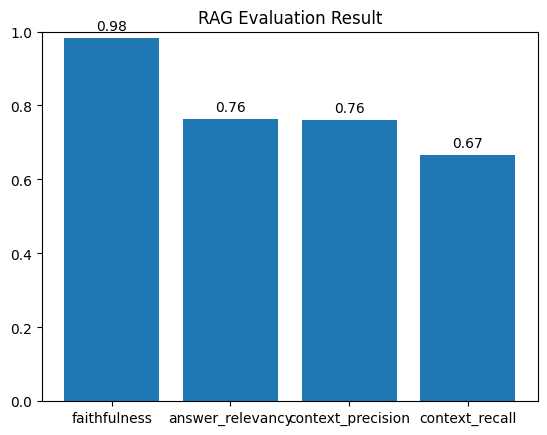

In [35]:
import matplotlib.pyplot as plt

scores = {
    'faithfulness': 0.9825,
    'answer_relevancy': 0.7638,
    'context_precision': 0.7611,
    'context_recall': 0.6667
}

plt.figure()
plt.bar(scores.keys(), scores.values())
plt.ylim(0,1)

for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.title("RAG Evaluation Result")
plt.show()